# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [37]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt# importar librerías

In [38]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [39]:
plans.head()# mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [40]:
users.head()# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [41]:
usage.head()# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [42]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [43]:
plans.info()# inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [44]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [45]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [46]:
# cantidad de nulos para users
print(users.isnull().sum()[users.isnull().sum()>0])# Cantidad de valores nulos)
print((users.isnull().mean().sort_values(ascending=False)*100)[(users.isnull().mean().sort_values(ascending=False)*100)>0])# Proporción de valores nulos)

city           469
churn_date    3534
dtype: int64
churn_date    88.350
city          11.725
dtype: float64


In [47]:
print(usage.isna().sum()[usage.isna().sum()>0])# cantidad de nulos para usage
print((usage.isnull().mean().sort_values(ascending=False)*100)[(usage.isnull().mean().sort_values(ascending=False)*100)>0])

date           50
duration    22076
length      17896
dtype: int64
duration    55.190
length      44.740
date         0.125
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción? <br>
     **R/ las columnas con valores faltantes en users:**<br>
      city : 11% <br>
      churn_date : 88% <br>
  
     **y en usage:** <br>
      date : 0.1% <br>
      duration : 55% <br>
      length : 44% <br>
- Indica qué harías: ¿imputar, eliminar, ignorar?<br>
  **R/** se identificaron valores faltantes en la columna **city**, pero se decidió ignorarlos porque la variable no era relevante para los objetivos del análisis.
    
    **churn_date** es una columna importante, ya que nos brinda la fecha de deserción. Los valores nulos también contienen información útil, porque indican que el usuario continúa activo, por lo que conservaría estos valores sin imputarlos.
    
    La columna **date** presenta solo un 0.1% de valores faltantes, por lo que eliminaría los registros afectados si esta variable es necesaria para realizar análisis temporales.
    
    Para **duration** (55%) y **length** (44%), no eliminaría las columnas automáticamente a pesar del alto porcentaje de valores faltantes. Primero investigaría el significado de estos valores y la relación entre ambas variables, ya que pueden ser relevantes para identificar patrones de consumo y segmentar clientes. Dependiendo de la causa de los valores faltantes, decidiría si imputarlos, conservarlos o finalmente excluir la variable. Evitaría una imputación automática con la media, ya que podría distorsionar el comportamiento real de los clientes.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [48]:
print(users['user_id'].describe())# explorar columnas numéricas de users
print(users['age'].describe())

count     4000.000000
mean     11999.500000
std       1154.844867
min      10000.000000
25%      10999.750000
50%      11999.500000
75%      12999.250000
max      13999.000000
Name: user_id, dtype: float64
count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64


- La columna `user_id` es consistente, los cuartiles están distribuidos de forma razonable 
- La columna `age` presenta un valor inválido (-999) en el mínimo, el cual probablemente corresponde a un valor centinela utilizado para representar datos faltantes.

In [49]:
print(usage['id'].describe())# explorar columnas numéricas de usage
print(usage['user_id'].describe())

count    40000.00000
mean     20000.50000
std      11547.14972
min          1.00000
25%      10000.75000
50%      20000.50000
75%      30000.25000
max      40000.00000
Name: id, dtype: float64
count    40000.000000
mean     12002.405975
std       1157.279564
min      10000.000000
25%      10996.000000
50%      12013.000000
75%      13005.000000
max      13999.000000
Name: user_id, dtype: float64



- Las columnas `id` y `user_id` presentan valores consistentes y no muestran valores fuera de los rangos esperados.
- La columna `id` contiene identificadores únicos en el rango de 1 a 40.000, mientras que `user_id` contiene identificadores de usuarios entre 10.000 y 13.999, por lo que es normal encontrar valores repetidos.


In [50]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` cuenta con 3531 datos, 7 datos únicos, la moda es la ciudad de Bogotá con una frecuencia de 808
- La columna `plan` cuenta con 4000 datos, 2 datos únicos, la moda es el plan Básico con una frecuencia de 2595

In [51]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` cuenta con 4000 datos, 2 únicos, la moda es "text" con una frecuencia de 22092


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y qué acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?<br>
    **R/** La columna `age` contiene un valor sentinel (-999)
- ¿Qué acción tomarías?<br>
    **R/** Reemplazaría el sentinel -999 por un valor nulo (NaN) y, si es necesario para segmentar los datos por edad, imputaría los valores faltantes utilizando la mediana de la columna age, ya que es menos sensible a valores extremos que la media.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [52]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors ="coerce")

In [53]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(users['reg_date'], errors ="coerce")

In [54]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: reg_date, dtype: object

En `reg_date`, se presentan inconcistencias con las fechas, ya que los registros deberian llegar hasta finales del 2024 no hasta 2026

In [55]:
# Revisar los años presentes en `date` de usage
usage['date'].describe()

count                    4000
unique                   3961
top       2026-05-10 00:00:00
freq                       40
first     2022-01-01 00:00:00
last      2026-05-10 00:00:00
Name: date, dtype: object

En `date`, misma inconsistencia que `reg_date` 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:


**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)<br>
  **R/** En ambas columnas se encuentran inconsistencias, ya que existen fechas posteriores a 2024. Estas fechas están fuera del período definido para el análisis.
- ¿Qué harías con ellas?<br>
  **R/** Deben ser revisadas para determinar su origen. Si corresponden a errores de registro, deberían corregirse; si no pueden validarse o corregirse, podrían excluirse del análisis.


---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [56]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [57]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace("?",pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [58]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [59]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean()*100

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [60]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean()*100

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Se puede observar que ambas columnas dependen directamente de la columna `type`. Aproximadamente el 99.9% de los mensajes de texto (text) no tiene duración (`duration`), mientras que aproximadamente el 99.9% de las llamadas (call) no tiene longitud (`length`).

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [61]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg(cant_mensajes=("is_text","sum"), cant_llamadas=("is_call","sum"), cant_minutos_llamada=("duration","sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [63]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile =  users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [64]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [65]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

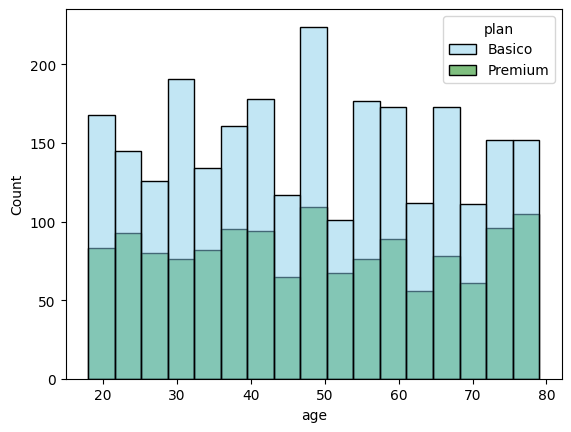

In [66]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights: 
- La edad no parece ser una variable diferenciadora entre planes. Los usuarios Premium y Básico tienen perfiles demográficos similares, por lo que probablemente la elección del plan no depende principalmente de la edad.

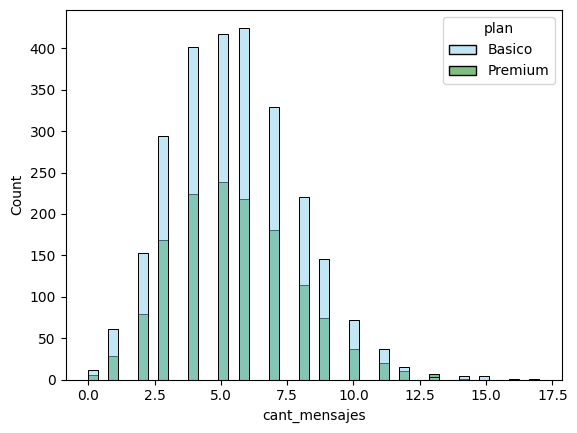

In [67]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights: 
- La mayoría de usuarios tienen una cantidad moderada de mensajes, mientras que pocos usuarios presentan una alta interacción. El comportamiento de uso de mensajes es similar entre planes, por lo que esta variable no parece explicar una diferencia clara entre Básico y Premium.

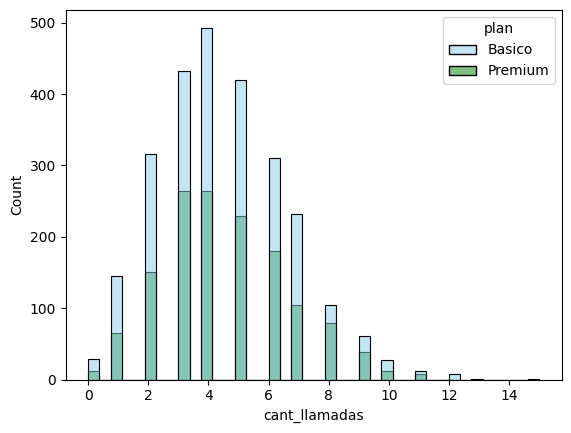

In [68]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights: 
- La cantidad de llamadas presenta un comportamiento concentrado en usuarios con bajo o medio uso, mientras que existe un grupo pequeño de usuarios con mayor actividad. No se evidencia una diferencia significativa entre usuarios Básico y Premium.

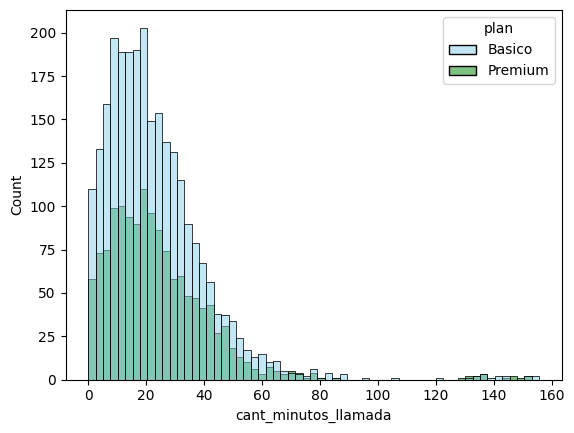

In [69]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.show()

💡Insights: 
- La duración de llamadas presenta una concentración en tiempos cortos y medios, con una distribución sesgada hacia la derecha debido a algunos usuarios con consumos elevados. El comportamiento es similar entre los planes Básico y Premium, por lo que la duración de llamadas por sí sola no parece ser un factor diferenciador fuerte entre planes.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

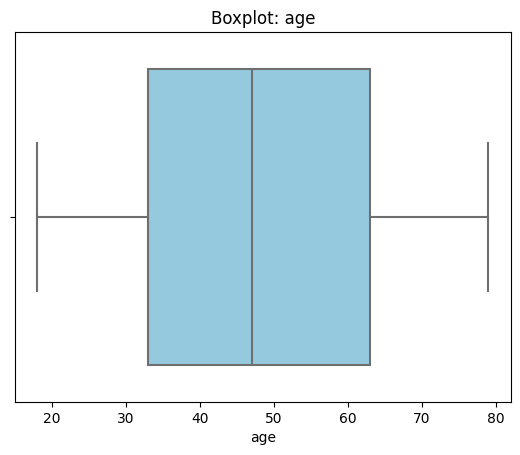

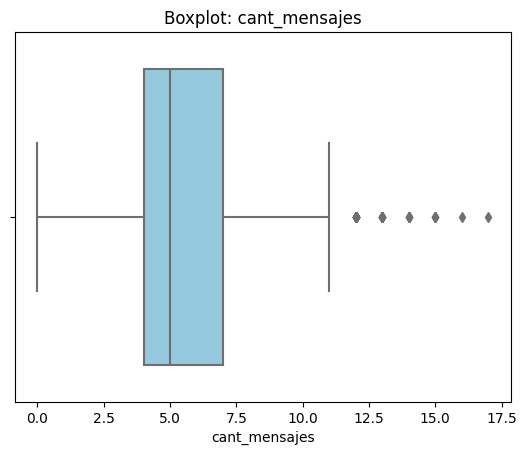

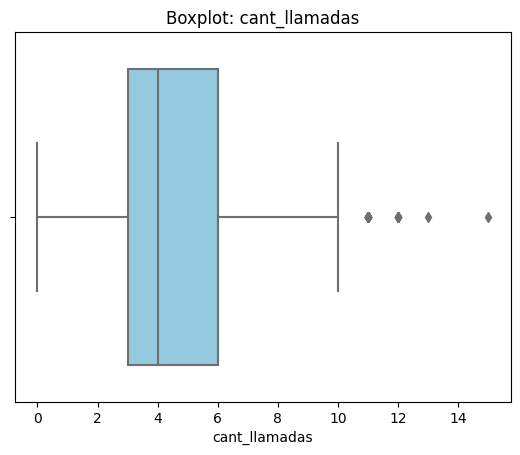

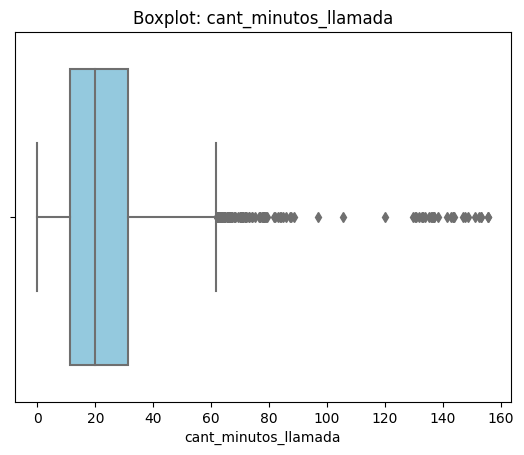

In [70]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)

    plt.show()

    


💡Insights: 
- **Age**: no se observan valores atípicos.
- **cant_mensajes**: se observan algunos valores atípicos, aunque son pocos en comparación con el total de los datos.
- **cant_llamadas**: se identifican algunos valores atípicos, pero su presencia es limitada.
- **cant_minutos_llamada**: se observa una cantidad considerable de valores atípicos, lo que indica una mayor dispersión en la duración de las llamadas.

In [73]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    cantidad = (user_profile[col] > upper).sum()
    print(col, ":", cantidad, "outliers")

cant_mensajes : 46 outliers
cant_llamadas : 30 outliers
cant_minutos_llamada : 109 outliers


In [72]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- `cant_mensajes`: Un usuario puede enviar una cantidad excepcionalmente alta de mensajes y eso puede representar un patrón real de consumo. Eliminarlo podría ocultar a los usuarios más intensivos.
- `cant_llamadas`: Una cantidad elevada de llamadas puede ser completamente válida. Puede identificar usuarios con un uso intensivo del servicio, lo cual es relevante para analizar comportamiento y planes.
- `cant_minutos_llamada`: Aunque haya pocos outliers, una duración elevada de llamadas puede ser un consumo real. Además, eliminar esos registros podría subestimar el consumo de los usuarios intensivos.

Se decidió mantener los outliers en `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada`, ya que estos valores extremos pueden representar usuarios que realmente tienen un consumo más alto de lo normal. Al ser variables relacionadas con el uso del servicio, eliminarlas podría hacer que perdiéramos información importante sobre los clientes con mayor consumo y afectar el análisis de sus patrones de uso.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [79]:
# Crear columna grupo_uso
def classify_uso(row):
    mensaje=row['cant_mensajes']
    llamada=row['cant_llamadas']
    if (mensaje<5) & (llamada<5):
        return 'Bajo uso'
    elif (mensaje<10) & (llamada<10):
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso']=user_profile.apply(classify_uso,axis=1)

In [80]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [85]:
# Crear columna grupo_edad

def classify_edad(row):
    edad=row['age']
    if (edad<30):
        return 'Joven'
    elif (edad<60):
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad']=user_profile.apply(classify_edad,axis=1)


In [86]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

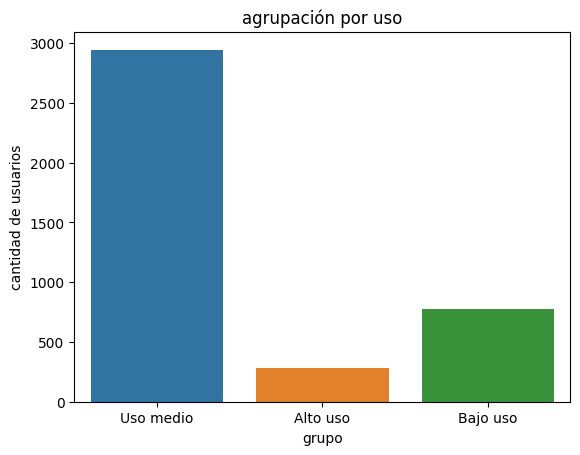

In [88]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('agrupación por uso')
plt.xlabel('grupo')
plt.ylabel('cantidad de usuarios')
plt.show()

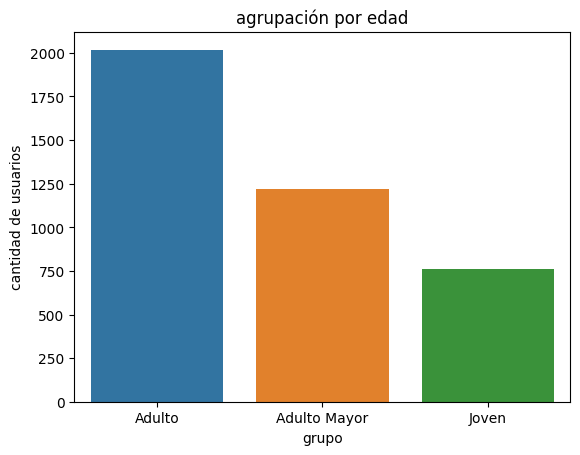

In [89]:
# Visualización de los segmentos por edad
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('agrupación por edad')
plt.xlabel('grupo')
plt.ylabel('cantidad de usuarios')
plt.show()

---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmente los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
   
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores faltantes en algunas variables. `date` tenía aproximadamente 0,1 % de valores faltantes, mientras que `duration` y `length` presentaban porcentajes mayores, de aproximadamente **55%** y **44%**, respectivamente.
  
- `city` también presentaba valores faltantes, pero se decidió ignorar esta variable, ya que la ciudad no era necesaria para los objetivos del análisis.

  
- Los valores nulos de `churn_date` se conservaron, ya que representan usuarios que continúan activos.

  
- También se identificaron algunos **outliers** en las variables de consumo, especialmente en `cant_minutos_llamada`. Estos se conservaron porque pueden representar usuarios con un consumo real mucho mayor al habitual.

🔍 **Segmentos por Edad**
- Se identificaron tres grupos de edad: **Jóvenes** (menores de 30 años), **Adultos** (entre 30 y 59 años) y **Adultos Mayores** (60 años o más).
  
- Esta clasificación permite comparar los diferentes niveles de uso según la edad y analizar si existen diferencias en los patrones de consumo entre los grupos.


📊 **Segmentos por Nivel de Uso**
- Se clasificaron los usuarios en tres grupos: **Bajo uso**, **Uso medio** y **Alto uso**, teniendo en cuenta la cantidad de llamadas y mensajes realizados.
  
- Los usuarios de **alto uso** que actualmente tienen el **plan básico** representan una oportunidad de crecimiento, ya que podrían ser candidatos para migrar al **plan premium**. Por otro lado, los usuarios de **alto uso** que ya tienen el **plan premium** representan principalmente una oportunidad de retención.

- Los usuarios de **bajo uso** probablemente tengan una menor necesidad de un **plan premium**, por lo que sería más conveniente mantenerlos en el **plan básico** y enfocarse en ofrecerles una opción que se ajuste a su consumo real.
  

➡️ Esto sugiere que **los clientes no tienen un comportamiento de consumo homogéneo**, por lo que ConnectaTel puede beneficiarse de una estrategia diferenciada según la **edad**, el **nivel de uso** y el **plan contratado**. Además, los usuarios con consumos extremos pueden representar una oportunidad para identificar necesidades específicas.


💡 **Recomendaciones**
- Implementar estrategias de **migración del plan básico al premium** para usuarios de **alto uso**, especialmente cuando su consumo indique que necesitan mayores beneficios.
  
- Desarrollar estrategias de **retención para los usuarios de alto uso** que ya tienen el **plan premium**.

- Para los usuarios de **uso medio**, especialmente aquellos que tienen el **plan básico**, **realizar campañas de migración cuando su consumo se acerque a los límites del plan actual**.

- Mantener una alternativa económica para los usuarios de **bajo uso**, evitando ofrecerles beneficios que probablemente no necesitan.

- Analizar los **outliers de consumo**, especialmente los relacionados con `cant_minutos_llamada`, para determinar si existe un grupo suficientemente grande que justifique la creación de un plan especializado para usuarios de consumo intensivo. 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`